In [14]:
# Bibliotecas que serão usadas no projeto
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import butter, resample_poly, savgol_filter, sosfilt, sosfilt_zi
from sklearn.linear_model import (
    Lasso,
    LassoCV,
    LinearRegression,
    MultiTaskLassoCV,
    Ridge,
    RidgeCV,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler  # type: ignore

# RNG padrão para reprodutibilidade
rng = np.random.default_rng(42)


---
### <a id='toc1_1_7_'></a>[Exemplo prático - EEG para prever tendência de movimento](#toc0_)

Antes de partirmos para o exemplo prático, desejo avisar o leitor sobre essa parte. Existem duas sessões desse desenvolvimento que não envolvem regularização nenhuma, apenas tratamento de dados e algumas discussões sobre o dataset. Por isso, caso o seu interesse seja somente a parte de Machine Learning, você poderá pular simplesmente para [Separação de dados em treino e teste](#toc1_1_7_3_), que já começa com a parte da separação dos dados. Agora, se você REALMENTE só deseja ver o modelo, você pode ir para [Modelos preditivos](#toc1_1_7_4_).

#### <a id='toc1_1_7_1_'></a>[Pegando os dados do Dataset](#toc0_)

Para iniciarmos essa seção, vamos discutir o que estamos buscando. Vamos usar um participante do dataset WAY-EEG-GAL <a id='toc0_'></a>[[9]](#toceq_9_) <a id='toc0_'></a>[[11]](#toceq_11_), essa base de dados conta com 32 canais de EEG e 5 canais de EMG <a id='toc0_'></a>[[11]](#toceq_11_). Esses dados são extremamente ruidosos e estão espalhados dentro de uma grande estrutura de dados. Antes de sequer sonharmos em extrairmos qualquer informação útil deles, precisamos separar e tratar cada um deles.

In [15]:
# pegando os arquivos

DATA_DIR = Path("data/raw/P1")
DATA_DIR.mkdir(parents=True, exist_ok=True)


ws_files = sorted(DATA_DIR.glob("WS_P1_S*.mat"))

print(f"Número de arquivos WS encontrados: {len(ws_files)}")

for arquivo in ws_files:
    print(arquivo.name)

# Converte um arquivo .mat para python puro: um dicionario
mat = loadmat(ws_files[0],simplify_cells=True)
ws=mat["ws"]
wins=ws["win"]
trial = wins[0]

eeg = trial["eeg"] #Resultado do EEG do paciente 1
# eeg_t = trial["eeg_t"]
eeg_names = ws["names"]["eeg"] #Nome de cada canal
kin_names = ws["names"]["kin"] #Nome dos sensores cinemáticos
kin = trial["kin"] #Dados cinemáticos
t = trial["eeg_t"] #Tempo de cada medida

print("Nome dos sensores do EEG:")

for i, nome in enumerate(eeg_names):
    print(i, nome, end="    ")
    if i%3==2:
        print()

Número de arquivos WS encontrados: 9
WS_P1_S1.mat
WS_P1_S2.mat
WS_P1_S3.mat
WS_P1_S4.mat
WS_P1_S5.mat
WS_P1_S6.mat
WS_P1_S7.mat
WS_P1_S8.mat
WS_P1_S9.mat
Nome dos sensores do EEG:
0 Fp1    1 Fp2    2 F7    
3 F3    4 Fz    5 F4    
6 F8    7 FC5    8 FC1    
9 FC2    10 FC6    11 T7    
12 C3    13 Cz    14 C4    
15 T8    16 TP9    17 CP5    
18 CP1    19 CP2    20 CP6    
21 TP10    22 P7    23 P3    
24 Pz    25 P4    26 P8    
27 PO9    28 O1    29 Oz    
30 O2    31 PO10    

Para usarmos esses dados, vamos fazer um caso reduzido: tentar prever a velocidade do punho no espaço. Para isso, vamos isolar o índice dos sensores de x, y e z do punho, referenciado como P4 <a id='toc0_'></a>[[11]](#toceq_11_). Esses dados descrevem a posição espacial no tempo dessa pessoa, que será particularmente útil quando tentarmos prever movimentação de uma prótese a partir de ondas cerebrais, que é uma das motivações dos autores do dataset WAY-EEG-GAL <a id='toc0_'></a>[[11]](#toceq_11_).

21 Px4 - position x sensor 4
25 Py4 - position y sensor 4
29 Pz4 - position z sensor 4


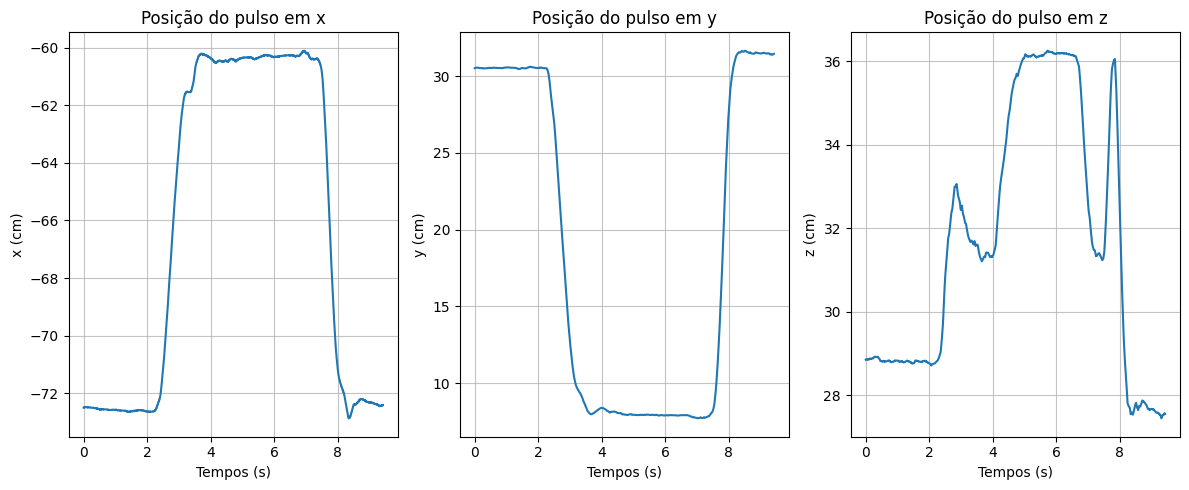

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharex=True)

p4_indices=[]

for i, nome in enumerate(kin_names):
    if "P" in str(nome) and "4" in str(nome):
        p4_indices.append(i)
        print(i, nome)

pulso_pos = kin[:, p4_indices]

dt=np.mean(np.diff(t))
fs=1/dt

labels=["x", "y", "z"]

for i in range(3):
    axes[i].plot(t, pulso_pos[:, i])
    axes[i].set_ylabel(f"{labels[i]} (cm)")
    axes[i].grid(alpha=0.75)
    axes[i].set_title(f"Posição do pulso em {labels[i]}")

    axes[i].set_xlabel("Tempos (s)")

plt.tight_layout()
plt.show()

Mas e a velocidade desse braço? Um jeito de achar esse valor seria dividir a variação da posição com a variação do tempo, mas isso vem com os seus próprios desafios. Digamos que o pulso quisesse permanecer parado, mas, naturalmente, ele se moveu $0.001 \ m$, com o dt sendo $0.002 \ s$ , esse simples ruido amplifica para uma velocidade de $0.5 \ \frac{m}{s}$. Por isso, espera-se que, usando esse método, o ruído do sinal fique muito alto.

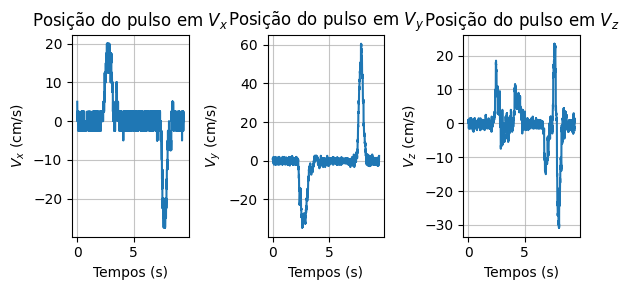

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(6, 3), sharex=True)

pulso_vel = np.gradient(pulso_pos, dt, axis=0)

labels=[r"$V_x$", r"$V_y$", r"$V_z$"]

for i in range(3):
    axes[i].plot(t, pulso_vel[:, i])
    axes[i].set_ylabel(f"{labels[i]} (cm/s)")
    axes[i].grid(alpha=0.75)
    axes[i].set_title(f"Posição do pulso em {labels[i]}")

    axes[i].set_xlabel("Tempos (s)")

plt.tight_layout()
plt.show()

Para resolver isso, usaremos uma função do scipy que suaviza sinais. Isso permite tentar reduzir o ruído amplificado pela derivada.

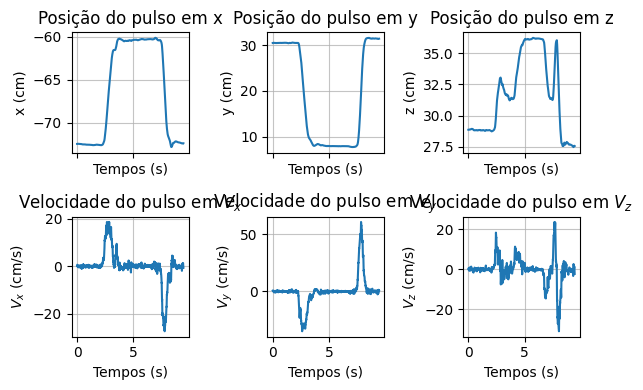

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4), sharex=True)
#o window_length precisa ser impar, além disso, estamos assumindo que o movimento ocorre a cada 40 ms, ja que 21/fs da aproximadamente 40 ms
window_length = 21
polinomio_ord = 3

pulso_pos_suave = savgol_filter(pulso_pos, window_length=window_length, polyorder= polinomio_ord, axis = 0)

labels=["x", "y", "z"]

for i in range(3):
    axes[0][i].plot(t, pulso_pos_suave[:, i])
    axes[0][i].set_ylabel(f"{labels[i]} (cm)")
    axes[0][i].grid(alpha=0.75)
    axes[0][i].set_title(f"Posição do pulso em {labels[i]}")

    axes[0][i].set_xlabel("Tempos (s)")

pulso_vel_suave = np.gradient(pulso_pos_suave, dt, axis=0)

labels=[r"$V_x$", r"$V_y$", r"$V_z$"]

for i in range(3):
    axes[1][i].plot(t, pulso_vel_suave[:, i])
    axes[1][i].set_ylabel(f"{labels[i]} (cm/s)")
    axes[1][i].grid(alpha=0.75)
    axes[1][i].set_title(f"Velocidade do pulso em {labels[i]}")

    axes[1][i].set_xlabel("Tempos (s)")

plt.tight_layout()
plt.show()

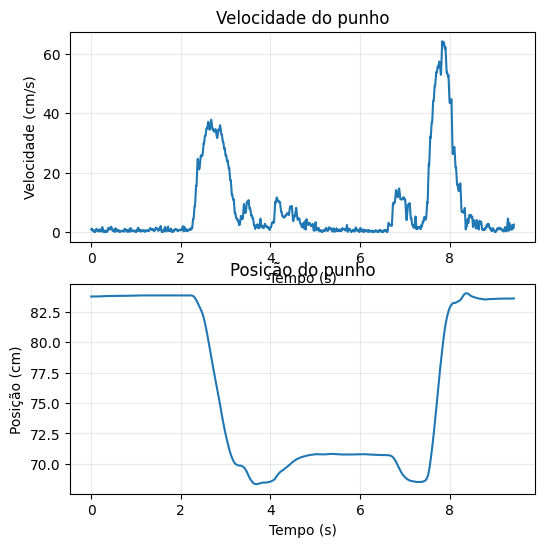

In [19]:
velocidade = np.linalg.norm(
    pulso_vel_suave,
    axis=1
)

posicao = np.linalg.norm(
    pulso_pos_suave,
    axis=1
)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

axes[0].plot(t, velocidade)

axes[0].set_xlabel("Tempo (s)")
axes[0].set_ylabel("Velocidade (cm/s)")
axes[0].set_title("Velocidade do punho")

axes[0].grid(alpha=0.25)

axes[1].plot(t, posicao)

axes[1].set_xlabel("Tempo (s)")
axes[1].set_ylabel("Posição (cm)")
axes[1].set_title("Posição do punho")

axes[1].grid(alpha=0.25)

plt.show()

#### <a id='toc1_1_7_2_'></a>[Tratando o EEG](#toc0_)

Agora, precisamos tratar o EEG para podermos usá-lo em treino e testo. Contudo, aqui que as coisas começam a dificultar. Primeiro lugar, os dados são temporalmente correlacionados, logo, pegar o ponto $e(t_i)$ para treinar o modelo e usar o $e(t_{i+1})$ para teste é incoerente. Porque? A informação que esse pontos carregam são quase que idênticas, então, o modelo teria uma acurácia incrível sem ter aprendido nada de verdade (já que estaríamos usando pontos que ele já conhece). Isso é um caso de **Data Leakage** <a id='toc0_'></a>[[1]](#toceq_1_) (isso é comentado dentro de uma célula em [Sistema Linear possível e indeterminado](#toc1_1_6_2_)) e ele é só uma das varias questões que rodeiam esse tipo de problema, cada uma será abordada quando for conveniente.

Para simplificar o problema, vamos usar somente um canal para trabalhamos. Nesse caso, o C3 é particularmente interessante, já que ele está na região onde fica o córtex sensorimotor contralateral <a id='toc0_'></a>[[11]](#toceq_11_). Não necessariamente ele terá a nossa resposta, mas é um bom casa para inspecionarmos. 

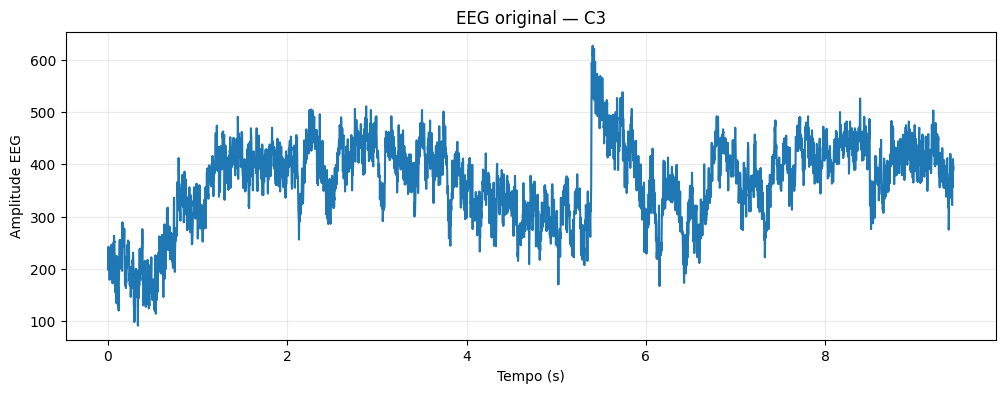

In [20]:
idx_c3 = list(eeg_names).index("C3")

plt.figure(figsize=(12, 4))

plt.plot(
    t,
    eeg[:, idx_c3]
)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude EEG")
plt.title("EEG original — C3")
plt.grid(alpha=0.25)

plt.show()

Veja o gráfico acima e se pergunte: você consegue achar uma correlação direta com o movimento? O EEG não terá indicativos visuais claros de que existe alguma tendencia ou algo do tipo, por isso, precisamos achar um jeito de extrair essa informação dele.

Como o EEG não tem um zero absoluto, é comum usar o **Comum Average Reference (CAR)** <a id='toc0_'></a>[[12]](#toceq_12_), que tira uma média de cada um dos canais e depois subtrai esse valor dos sinais existentes.

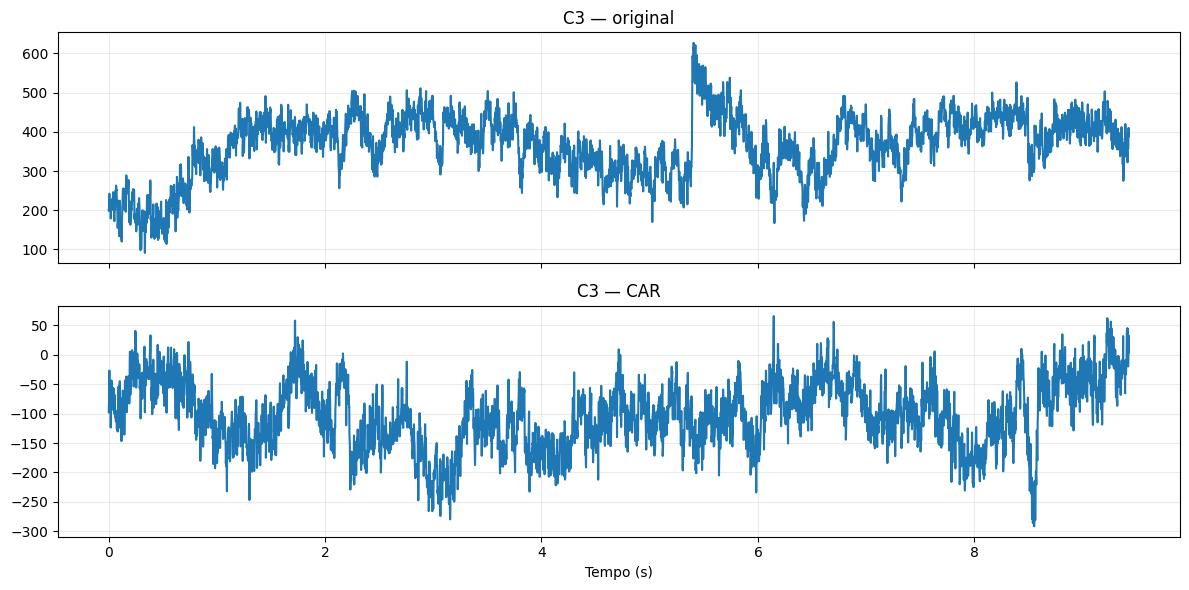

In [21]:
eeg_car = eeg - eeg.mean(axis=1, keepdims=True)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 6),
    sharex=True
)

axes[0].plot(
    t,
    eeg[:, idx_c3]
)

axes[0].set_title("C3 — original")
axes[0].grid(alpha=0.25)

axes[1].plot(
    t,
    eeg_car[:, idx_c3]
)

axes[1].set_title("C3 — CAR")
axes[1].set_xlabel("Tempo (s)")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Agora, precisamos filtrar o que buscamos para esse problema. Existe um estudo interessante que realiza exatamente o que buscamos aqui <a id='toc0_'></a>[[10]](#toceq_10_), nossa abordagem será muito baseada na dele. O estudo revela que componentes lentas do sinal são particularmente úteis para previsão de velocidade <a id='toc0_'></a>[[10]](#toceq_10_), por isso, vamos seguir o pipeline do artigo. O primeiro passo será realizar um downsampling, no momento, temos 500 amostras por segundo <a id='toc0_'></a>[[11]](#toceq_11_), e o artigo menciona que 100 Hz é suficiente <a id='toc0_'></a>[[10]](#toceq_10_). 

Entretanto, só pegar amostras de 5 em 5 seria incorreto, já que geraria erro de **aliasing** <a id='toc0_'></a>[[13]](#toceq_13_). Por isso, faremos uma reamostragem usando o resample_poly <a id='toc0_'></a>[[13]](#toceq_13_) e para diminuir a frequência usaremos a função butter <a id='toc0_'></a>[[13]](#toceq_13_) do scipy.

In [22]:
eeg_100 = resample_poly(eeg_car, up=1, down=5, axis=0)

t_100=np.arange(len(eeg_100))/100
t_100+=t[0]

sos = butter(
    N=4, #ordem do filtro
    Wn=1.0, #frequencia de 1 Hz
    btype="lowpass", #passa baixos
    fs=100, #frequencia atual
    output="sos" #uma representação numerica estavel
)



Normalmente, usaríamos sosfiltfilt <a id='toc0_'></a>[[13]](#toceq_13_) como filtro, mas ele apresenta um problema nessa prática: ele não é causal. Ele usaria dados futuros de *t* para filtrar e isso fere um pouco a tentativa de prever uma intensão (é uma previsão se já espiamos o futuro?). Por isso, vamos usar sosfilt <a id='toc0_'></a>[[13]](#toceq_13_) e sosfilt_zi <a id='toc0_'></a>[[13]](#toceq_13_) para criar um filtro causal.

In [23]:
def filtro_causal(eeg, sos):
    eeg_filtrado = np.empty_like(eeg)

    zi = sosfilt_zi(sos)

    for canal in range(eeg.shape[1]):

        sinal = eeg[:, canal]

        filtrado, _ = sosfilt(
            sos,
            sinal,
            zi=zi*sinal[0]
        )

        eeg_filtrado[:, canal]=filtrado

    return eeg_filtrado

eeg_low = filtro_causal(eeg_100, sos)

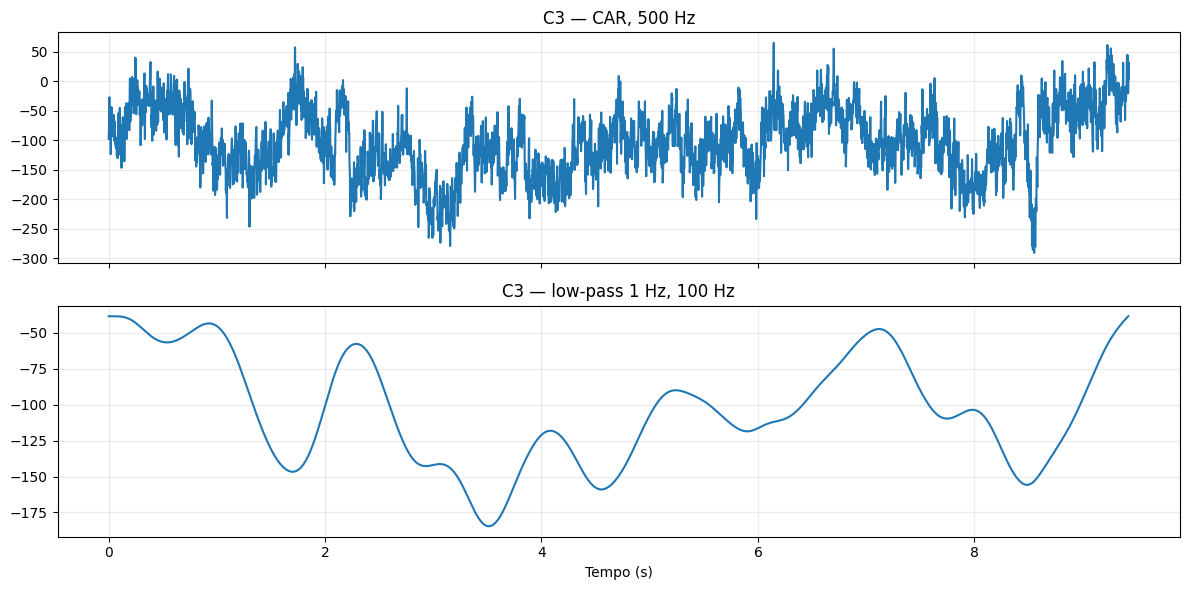

In [24]:
fig, axes = plt.subplots( 2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(
    t,
    eeg_car[:, idx_c3]
)

axes[0].set_title("C3 — CAR, 500 Hz")
axes[0].grid(alpha=0.25)


axes[1].plot(
    t_100,
    eeg_low[:, idx_c3]
)

axes[1].set_title("C3 — low-pass 1 Hz, 100 Hz")
axes[1].set_xlabel("Tempo (s)")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Analisando os novos sinais, é possível ver uma enorme diferença. A nova variável permite analisar a dinâmica lenta do sinal, por isso tem uma forma parecida e deslocada do sinal original. 

Mas porque estudar isso? Queremos achar uma relação linear do tipo:

$$v_x(t)\approx \sum_{c=1}^{32} \sum_{k=0}^K \omega_{c,k}EEG_c(t-k)$$

Em que $c$ é o eletrodo correspondente e $k$ é o atraso temporal. Poderíamos fazer a regularização L1 ajudar a eliminar combinações específicas de $\omega_{c,k}$ para, posteriormente, aplicar L2 para ajustar a contribuição de eletrodos distintos, mas isso tornaria esse notebook muito complexo, por isso, não será feito. Isso vem de uma interpretação neurofisiológica mais profunda, da não independência das regiões do cérebro. Sabemos que não existe um local do cérebro responsável por todos os movimentos e isso conversa intrinsecamente com a natureza dos reguladores.

Obviamente, não poderemos automaticamente inferir que, se o modelo for bem sucedido, isso é uma consequência do que fizemos. O dataset não menciona que coisas como o movimento dos olhos, piscadas e outras coisas foram removidas nem tratadas. Logo, existe a chance do paciente mexer o olho toda ver que move o pulso, então, o nosso modelo pode aprender que essas interações são causais. Isso será abordado novamente mais tarde.

Antes de prosseguirmos, vamos fazer um downsampling das velocidades também.

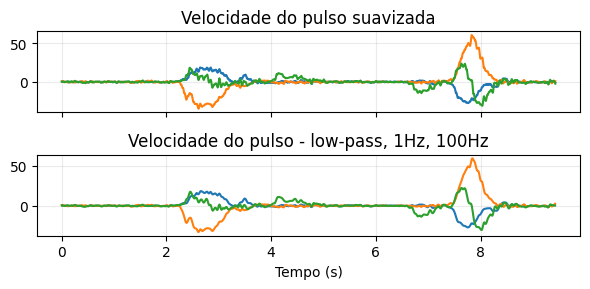

In [25]:

vel = savgol_filter(
    pulso_pos_suave,
    window_length=50,
    polyorder=3,
    deriv=1,
    delta=dt,
    axis=0
)

pulso_vel_100 = resample_poly(
vel,
up=1,
down=5,
axis=0
)

fig, axes = plt.subplots(2, 1, figsize=(6, 3), sharex=True)

axes[0].plot(
    t,
    pulso_vel_suave
)

axes[0].set_title("Velocidade do pulso suavizada")
axes[0].grid(alpha=0.25)


axes[1].plot(
    t_100,
    pulso_vel_100
)

axes[1].set_title("Velocidade do pulso - low-pass, 1Hz, 100Hz")
axes[1].set_xlabel("Tempo (s)")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


A diferença é basicamente invisível, mas ela possibilitará com que o código funcione no futuro.

#### <a id='toc1_1_7_3_'></a>[Separação de dados em treino e teste](#toc0_)

Até agora, so tratamos os dados e discutimos a relação de $EEG(t-T, t) \to v(t+k)$, mas agora está na hora de começarmos a pensar no modelo em si. Primeiro, o que significa ele receber uma janela? No momento, temos algo do tipo:

$$
\begin{bmatrix}
C_1(t-k) & C_2(t-k) & \dots & C_n(t-k) \\
C_1(t-(k-1)) & C_2(t-(k-1)) & \dots & C_n(t-(k-1)) \\
C_1(t-(k-2)) & C_2(t-(k-2)) & \dots & C_n(t-(k-2)) \\
 \vdots & \vdots & \ddots & \vdots \\
 C_1(t) & C_2(t) & \dots & C_n(t)
\end{bmatrix}
$$

Porém, a regressão linear espera um grande vetor na forma de $[x_1,x_2, \dots, x_n]$. Por isso precisamos achatar essa matriz, isso pode ser feito alinhando cada coluna dentro do vetor. O numpy consegue fazer isso facilmente, os números que você vê a seguir são variáveis de teste, no momento, estamos chutando um valor aleatório, mas isso seria obtido empiricamente. A única variável que foi escolhida com certo pudor foi o ms_step. Lembre-se de que se o step for muito perto o sinal irá ter muita similaridade e explicar as mesmas informações, esse foi o motivo de escolhermos $50 \ ms$.

In [26]:
def cria_janela(
        eeg,
        velocidade,
        fs=100,
        ms_janela=500,
        ms_previsao=100,
        ms_step=50
):
    tamanho_janela = int(ms_janela/1000*fs)
    tamanho_previsao = int(ms_previsao/1000*fs)
    tamanho_step = int(ms_step/1000*fs)

    X=[]
    Y=[]

    primeiro_t= tamanho_janela-1
    ultimo_t= len(eeg)-tamanho_previsao

    for i in range(primeiro_t, ultimo_t, tamanho_step):
        janela = eeg[ i - tamanho_janela + 1 : i + 1].T.reshape(-1)
        target = velocidade[i+tamanho_previsao]

        X.append(janela)
        Y.append(target)

    #Vamos construir os nomes de cada canal para nos acharmos depois
    feature_names = []
    lags_ms = np.arange(
        -(tamanho_janela - 1),
        1
    ) * 1000 / fs

    for canal in eeg_names:
        for lag in lags_ms:

            feature_names.append(
                f"{canal}_{lag:.0f}ms"
            )

    return np.asarray(X), np.asarray(Y), np.asarray(feature_names)


X_trial, Y_trial, nomes_trial = cria_janela(eeg_low, pulso_vel_100)

print("X: ", X_trial.shape)
print("Y: ", Y_trial.shape)
print("Nomes: ", nomes_trial[:10])

X:  (177, 1600)
Y:  (177, 3)
Nomes:  ['Fp1_-490ms' 'Fp1_-480ms' 'Fp1_-470ms' 'Fp1_-460ms' 'Fp1_-450ms'
 'Fp1_-440ms' 'Fp1_-430ms' 'Fp1_-420ms' 'Fp1_-410ms' 'Fp1_-400ms']


Agora, antes de usarmos o train_test_split, precisamos separar as janelas em grupos. Porque? Simples, pegar janelas subsequentes para treino e teste seria contra produtivo, já que janelas consecutivas explicam informações muito parecidas. Por isso, o treino será feito em trials, em que cada trial poderá ser composto somente por treino ou teste, nunca ambos. Para isso, usaremos o GroupShuffleSplit <a id='toc0_'></a>[[14]](#toceq_14_).

In [27]:
groups_trial = np.full(len(X_trial), 0)

X= np.vstack(X_trial)
Y= np.vstack(Y_trial)

Para realmente tentar criar um modelo preditivo nesse caso, precisaríamos percorrer os arquivos do dataset e adicioná-los em blocos. Para isso, essa próxima célula será um grande apanhado do que foi feito anteriormente, para que possamos percorrer todos os arquivos.

In [28]:
def load_arquivos():

    ws = []
    wins = []

    for i in ws_files:
        mat = loadmat(i, simplify_cells=True)
        ws.append(mat["ws"])
        wins.append(mat["ws"]["win"])

    return wins, ws

def indices_vel(ws:dict):

    p4_indices = []

    for wss in ws:
        nome_kin = wss["names"]["kin"]

        p4_indices.append([i for i, nome in enumerate(nome_kin) if ("P" in str(nome) and "4" in str(nome))])

    return p4_indices

def processa_eeg(
        eeg,
        N=4,
        Wn=1.0,
        fs=100
        ):

    eeg_car = eeg - eeg.mean(axis=1, keepdims=True)
    eeg_100 = resample_poly(eeg_car, up=1, down=5, axis=0)

    sos = butter(
    N=N, #ordem do filtro 
    Wn=Wn, #frequencia de 1 Hz
    btype="lowpass", #passa baixos
    fs=fs, #frequencia atual
    output="sos" #uma representação numerica estavel
    )

    eeg_tratado = filtro_causal(eeg_100, sos)

    return eeg_tratado

def processa_vel(
        kin,
        indices,
        dt,
        polinomio_ord=3,
        window_length = 50,
        down=5
                 ):

    vel_pos_suave = savgol_filter(
        kin[:, indices], 
        window_length=window_length, 
        polyorder= polinomio_ord, 
        deriv=1, 
        delta=dt,
        axis = 0
        )
    vel_100 = resample_poly(
        vel_pos_suave,
        up=1,
        down=down,
        axis=0
    )

    return vel_100
    
    

def cria_grupos():

    X_blocos=[]
    Y_blocos=[]
    groups_blocos=[]

    trial_id=0

    wins, ws = load_arquivos()
    p4_indices = indices_vel(ws)

    for j in wins:
        for i, trial in enumerate(j):
            eeg=np.asarray(trial["eeg"], dtype=np.float32)
            kin=np.asarray(trial["kin"])
            t=np.asarray(trial["eeg_t"]).squeeze()

            dt = np.median(np.diff(t))

            eeg_processado = processa_eeg(eeg)
            vel_processada = processa_vel(kin, p4_indices[0], dt)

            N=min(len(eeg_processado), len(vel_processada))

            eeg_processado=eeg_processado[:N]
            vel_processada=vel_processada[:N]

            X_trial, Y_trial, nomes_trial = cria_janela(
                eeg_processado,
                vel_processada
            )

            groups_trial = np.full(
                len(X_trial),
                trial_id
            )

            X_blocos.append(X_trial)
            Y_blocos.append(Y_trial)
            groups_blocos.append(groups_trial)

            trial_id+=1

    return np.vstack(X_blocos), np.vstack(Y_blocos), np.concatenate(groups_blocos), nomes_trial

X, Y, grupos, nomes = cria_grupos()


print("X: ", X.shape)
print("Y: ", Y.shape)

X:  (47315, 1600)
Y:  (47315, 3)


Uma coisa interessante de cada trial é que nem todos tem o mesmo tamanho. Veja o gráfico abaixo, a grande maioria dos trials tem um tamanho entre 155 e 160. Mesmo que alguns ultrapassem, nenhum deles ultrapassou um número muito grande, isso pode simbolizar que nada de estranho aconteceu, já que o dataset descreve que tentou manter a uniformidade das medidas.

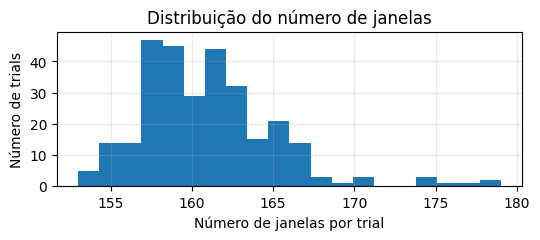

In [29]:
trial_ids, contagens = np.unique(
    grupos,
    return_counts=True
)

plt.figure(figsize=(6, 2))

plt.hist(
    contagens,
    bins=20
)

plt.xlabel("Número de janelas por trial")
plt.ylabel("Número de trials")
plt.title("Distribuição do número de janelas")

plt.grid(alpha=0.25)
plt.show()

Agora, precisamos separar o nosso trial em test e train. Porém, como comentamos antes, não podemos fazer isso com o train_test_split. Isso faria com que o modelo recebesse de teste características que ele já obteve a resposta, representando um **data_leakage**. Por isso, vamos usar o GroupShuffleSplit.

In [30]:
gss=GroupShuffleSplit(
    n_splits= 1,
    test_size=0.20,
    random_state=42
)
train_idx, test_idx = next(
    gss.split(
        X,
        Y,
        groups=grupos
    )
)

X_train = X[train_idx]
X_test = X[test_idx]

Y_train = Y[train_idx]
Y_test = Y[test_idx]

grupos_train = grupos[train_idx]
grupos_test = grupos[test_idx]

# para verificar leakage, vamos ver quando valores estao no mesmo grupo de um trial
sobreposicao = np.intersect1d(
    np.unique(grupos_train),
    np.unique(grupos_test)
)

print(sobreposicao)

[]


Essa lista vazia demonstra que a nossa forma de train_test_split conseguiu fazer uma distribuição que não tenha leakage. O que fizemos foi criar vários grupos que foram identificados como treino ou teste, mas nunca ambos. isso significa que o modelo não usa dados correlacionados temporalmente para tentar prever o movimento resultante do modelo.

#### <a id='toc1_1_7_4_'></a>[Modelos preditivos](#toc0_)

Agora, finalmente, vamos criar os modelos de leitura do EEG. Cada um tem uma lógica própria, mas todos tentam responder a mesma pergunta: **existe informação preditiva dentro de um EEG?** Não só isso, será que L1 e L2 ajudam a extrair essas informações?

Para começarmos, vamos criar os baselines para podermos comparar. O primeiro será um modelo que, para qualquer valor do EEG, sempre irá chutar que a mão está parada, já o segundo sempre chutará a média da velocidade do treino. Isso pode parecer ridículo, e até que é, mas ele é essencial para compararmos desempenho de qualquer outra coisa que faremos. Pelo dataset, a maior parte do tempo o pulso está em repouso, logo, o primeiro modelo pode ter um desempenho surpreendentemente boa, mesmo não prevendo nada. Já o segundo pode se sobressair em um trial que apresenta mais movimento. Isso define boas barreiras que o L1 e o L2 devem superar.



In [31]:
#primeiro baseline
Y_pred_base = np.zeros_like(Y_test)

#Segundo baseline
vel_media = Y_train.mean(axis=0)
Y_pred_mean = np.tile(
    vel_media,
    (len(Y_test), 1)
)

Agora, faremos uma função que fornece os erros do modelo. Vamos usar as métricas usadas anteriormente nos dois testes teóricos.

In [32]:
def avaliador_2000(Y_true, Y_pred):
    rmse = []
    mae = []
    r2 = []

    for eixo in range(3):

        rmse.append(
            mean_squared_error(Y_true[:, eixo], Y_pred[:, eixo])**0.5
        )

        mae.append(
            mean_absolute_error(Y_true[:, eixo], Y_pred[:, eixo])
        )

        r2.append(
            r2_score(Y_true[:, eixo], Y_pred[:, eixo])
        )

    erro_3d= Y_true-Y_pred

    rmse_3d = np.sqrt(
        np.mean(
            np.sum(
                erro_3d**2,
                axis=1
            )
        )
    )
    return {
        "RMSE_x": rmse[0],
        "RMSE_y": rmse[1],
        "RMSE_z": rmse[2],

        "MAE_x": mae[0],
        "MAE_y": mae[1],
        "MAE_z": mae[2],

        "R2_x": r2[0],
        "R2_y": r2[1],
        "R2_z": r2[2],

        "RMSE_3D": float(rmse_3d)
    }

erro_base = avaliador_2000(Y_test, Y_pred_base)
erro_mean = avaliador_2000(Y_test, Y_pred_mean)

print("Baseline que só chuta 0")
print()
for i in erro_base:
    print(i, erro_base[i])

print("----------------------------------------------------------------")
print("Baseline que só chuta a média")
print()
for i in erro_mean:
    print(i, erro_mean[i])

Baseline que só chuta 0

RMSE_x 9.152010667467767
RMSE_y 17.2444153919798
RMSE_z 7.4001911022172315
MAE_x 3.858986049378021
MAE_y 6.826492988363807
MAE_z 3.8628362638323575
R2_x -0.00017160204204436091
R2_y -0.000192059890476326
R2_z -6.898923401643664e-05
RMSE_3D 20.87802648283426
----------------------------------------------------------------
Baseline que só chuta a média

RMSE_x 9.151230053248806
RMSE_y 17.242769532990003
RMSE_z 7.399944785419058
MAE_x 3.878953245548323
MAE_y 6.873428041691103
MAE_z 3.865410996565414
R2_x -9.914722707282664e-07
R2_y -1.1463108717801873e-06
R2_z -2.4153608977339758e-06
RMSE_3D 20.876237579663226


Como esperado, os modelos de baseline são ruins no quesito de previsão. Analisando os gráficos da velocidade, eles tem um erro quadrático médio de aproximadamente 25% do valor máximo de cada componente e um absoluto um pouco maior do que 10%. Isso significa que, mesmo sendo extremamente idiota, o erro não está tão grande assim. Não há variações muito gritantes na posição da mão, já que as tarefas realizadas no estudo foram simples, logo, o regime médio ou de repouso é o mais frequente. 

Além disso, analisando os $R^2$, veja que ele é próximo do $0$. Isso, na realidade, é bem esperado, o baseline do $R^2$ é tirando exatamente a média, ver que ambos se aproximaram muito nos permite inferir que, provavelmente, a média é proxima de $0$, para que o primeiro modelo tivesse uma performance muito parecida com o segundo. Com isso, definimos boas métricas de desempenhos para os outros modelos.

Primeiro, o OLS simples. Vamos ver como o modelo se comporta sem nenhuma regularização

In [33]:
ols = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

ols.fit(X_train, Y_train)
Y_pred_ols= ols.predict(X_test)

resultado_ols = avaliador_2000(Y_test, Y_pred_ols)

print("Modelo OLS")
print()
for i in resultado_ols:
    print(i, resultado_ols[i])

Modelo OLS

RMSE_x 7.390743718293756
RMSE_y 14.099833369402553
RMSE_z 6.663813564624676
MAE_x 5.080020185167589
MAE_y 9.439511963528004
MAE_z 4.3599653893047075
R2_x 0.3477444698309713
R2_y 0.33132603926058857
R2_z 0.18905805037897028
RMSE_3D 17.257891093018642


Analisando suas estatísticas, veja que o modelo do OLS ainda tem um erro alto, mas já é uma melhora impressionante principalmente pela simplicidade. Ele ainda contém um erro alto, com o RMSE atingindo $28%$ do total e o MAE atingindo $11%$ desse mesmo máximo. Isso pode parecer incrivel a primeira vista, como um dos modelos mais básicos conseguiu uma previsão relativamente boa somente com um simples fit? Devemos lembrar que estamos lidando com $47315$ exemplos de EEG, o OLS se beneficia de dataset muito grandes e como, nesse caso, temos mais exemplos do que parâmetros, o OLS tem a possibilidade se ajustar bem. Por isso, OLS tende a estabilizar quando temos dados demais, dando resultados interessantes para esse tipo de caso. 

Contudo, não confunda. O OLS é melhor que os baselines, mas ele ainda não se aproxima do bom. Ter um erro de $28%$, por exemplo, pode resultar em uma divergência enorme em poucos passo. Pense que temos incerteza de até um quarto da medida, logo, se a velocidade do pulso é $10 \ \frac{cm}{s}$, não temos certeza nem da casa da unidade, acima de $40 \ \frac{cm}{s}$ já não podemos garantir a casa da dezena.

Por isso, é extremamente importante entender o seu problema, não só para tratar corretamente os dados, mas para saber quando algo pode ou não pode resolver o problema. Nesse caso, usar regressão linear sem nenhuma hipótese era quase que um caso condenado ao fracasso.

Antes de partirmos para as regularizações, porque não fazemos uma hipótese sobre os dados? Podemos usar CrossValidation de forma independente em três modelos distintos para prever o melhor hiperparâmetro de cada eixo. Assim, assumimos o seguinte:

**E se as dificuldade de previsão de um eixo não se traduzem na previsão dos outros?**

Isso permite buscarmos um modelo que prevê por eixo, infelizmente o OLS não tem hiperparâmetros para ajustar por eixos, por isso, não poderemos aplicar essa hipótese nele.

In [34]:
def busca_modelo_eixo_CV(
        modelo,
        param_grid,
        X_train,
        Y_train,
        grupos_train,
        cv
):

    buscas = []
    mse = []

    cv_folds = list(cv.split(X_train, groups=grupos_train))

    for eixo in range(3):

        minimo=[float("inf"), 0]

        if modelo =="L1":
            for i, alpha in enumerate(param_grid["lasso__alpha"]):

                print(f"\r{100*(i)/len(param_grid["lasso__alpha"]):.2f} %", end="")

                busca = make_pipeline(
                    StandardScaler(),
                    Lasso(
                            alpha= alpha,
                            max_iter=3000,
                            tol=1e-3,
                            warm_start=True,
                            selection= "random",
                            random_state=42
                            )
                        )
                
                scores = cross_val_score(
                    busca,
                    X_train,
                    Y_train[:, eixo],
                    n_jobs=-1,
                    cv=cv_folds,
                    scoring="neg_mean_squared_error"
                    )

                if -scores.mean()<minimo[0]:
                    minimo[0]=-scores.mean()
                    minimo[1]=busca

                
                mse.append(-scores.mean())


        else:
            for i, alpha in enumerate(param_grid["ridge__alpha"]):

                print(f"\r{100*(i)/len(param_grid["ridge__alpha"]):.2f} %", end="")

                busca = make_pipeline(
                    StandardScaler(),
                    Ridge(
                            alpha= alpha,
                            max_iter=3000,
                            solver="lsqr",
                            random_state=42
                            )
                        )

                scores = cross_val_score(
                    busca,
                    X_train,
                    Y_train[:, eixo],
                    n_jobs=-1,
                    cv=cv_folds,
                    scoring="neg_mean_squared_error"
                    )

                if -scores.mean()<minimo[0]:
                    minimo[0]=-scores.mean()
                    minimo[1]=busca
                
                
                mse.append(-scores.mean())

        print("\r100 %", end="\n")

        minimo[1] = minimo[1].fit(X_train, Y_train[:, eixo])
        busca = minimo[1]

        buscas.append(busca)

    return buscas, mse

Agora, partimos para a regularização L2. Aqui partimos para uma hipótese interessante, estamos supondo que os eletrodos tem várias informações redundantes e que a resposta está em permitir que cada um contribua com a resposta. Como faremos o CV na mão dessa vez, vamos usar o <span style="color:#97E1F1">Ridge</span>() e o <span style="color:#97E1F1">Lasso</span>(). Os parâmetros obtidos nesse caso serão discutidos posteriormente.

In [35]:
ridge = "L2"

alphas_ridge = np.logspace(
    2,
    3,
    30
)
ridge_grid = {
    "ridge__alpha": alphas_ridge
}
gkf = GroupKFold(n_splits=3)

ridge_busca, ridge_score = busca_modelo_eixo_CV(
    ridge,
    ridge_grid,
    X_train,
    Y_train,
    grupos_train,
    cv=gkf
)

Y_pred_ridge = np.column_stack([
    busca.predict(X_test) for busca in ridge_busca
])



100 % %
100 % %
100 % %


Agora que o modelo está treinado, vamos conferir os $\lambda$'s usados.

In [36]:
nomes_eixos = ["x", "y", "z"]

for eixo, busca in zip(
    nomes_eixos,
    ridge_busca
):

    print(
        eixo,
        busca[-1].alpha
    )

x 161.02620275609394
y 188.73918221350976
z 188.73918221350976


Algo interessante de se notar, cada eixo pareceu precisar de um $\lambda$ diferente. Isso não comprova, mas é um indicio interessante de que, para encontrar o modelo que melhor prevê, ele julgou que a melhor abordagem é aumentar a regularização em alguns eixos e diminuir nos outros.

Mesmo com essa diferença, ainda sim os valores são muito parecidos. Isso era levemente esperado, não parece ter alguma preferência por movimento em algum eixo, então, ver que a hipótese dos eixos independentes se mostrou uma preferência real é uma surpresa. Contudo, será que esse realmente é o melhor caminho? Vamos ver em relação ao Ridge sem diferenciação axial.

In [37]:
resultado_ridge = avaliador_2000(Y_test, Y_pred_ridge)

print("Resultados Ridge (eixos diferenciados)")
print()
for i in resultado_ridge:
    print(i, resultado_ridge[i])

print("-----------------------------------------------")


gkf = GroupKFold(n_splits=3)
cv_folds = list(gkf.split(X_train, groups=grupos_train))

ridge_se = make_pipeline(
    StandardScaler(),
    RidgeCV(
        alphas=alphas_ridge,
        cv=cv_folds
    )
)

ridge_se.fit(X_train, Y_train)
Y_pred_ridge_se = ridge_se.predict(X_test)

resultado_ridge_se = avaliador_2000(Y_test, Y_pred_ridge_se)
print("Resultados Ridge (eixos não diferenciados)")
print()
for i in resultado_ridge_se:
    print(i, resultado_ridge_se[i])

Resultados Ridge (eixos diferenciados)

RMSE_x 7.872509375165766
RMSE_y 15.013575708454308
RMSE_z 6.974713303727939
MAE_x 4.965117393040927
MAE_y 9.145763501291185
MAE_z 4.263578756889756
R2_x 0.2599384224907385
R2_y 0.2418507188040716
R2_z 0.11162401159594959
RMSE_3D 18.331134309822776
-----------------------------------------------
Resultados Ridge (eixos não diferenciados)

RMSE_x 7.863539579791761
RMSE_y 14.987137271342107
RMSE_z 6.964945963375572
MAE_x 4.942918976771473
MAE_y 9.123380295425184
MAE_z 4.251407955027601
R2_x 0.2616238874104949
R2_y 0.24451852210484704
R2_z 0.11411042060148469
RMSE_3D 18.30191275757113


Aqui podemos comparar o modelo com e sem a diferenciação de eixos. Note que o desempenho entre eles não muda muito um em relação ao outro, podemos usar o erro 3D para falar que o modelo de eixos não diferenciados erra um pouco menos, mas isso não é gritante o suficiente para afirmar que um é melhor que o outro. Em geral, o modelo é pior que o OLS, mas existe uma discussão a ser feita nesse quesito. Guardaremos ela para a sessão final desse notebook.

Enfim, vamos para a regularização L1. Agora iremos idealizar a seguinte hipótese: e se poucas janelas temporais dos eletrodos são necessários para explicar o movimento do pulso? Ou seja, a representação do movimento é esparsa no espaço canal-tempo? Pensar nisso é idealizar que as regiões que são responsáveis pelo fenômeno do movimento do pulso são bem definidas e que os outros sinais pegam apenas resíduos dessa região. Logo, para explicar esse movimento, não seria necessário considerar todos os canais, apenas alguns.

In [38]:
lasso = "L1"

alphas_lasso = np.logspace(
    -3,
    -1,
    8
)[::-1]
lasso_grid={
    "lasso__alpha":alphas_lasso
}

gkf = GroupKFold(n_splits=3)

lasso_busca, lasso_score = busca_modelo_eixo_CV(
    lasso,
    lasso_grid,
    X_train,
    Y_train,
    grupos_train,
    cv=gkf
)

Y_pred_lasso = np.column_stack([
    busca.predict(X_test) for busca in lasso_busca
])

100 % %


C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.921900e+04, tolerance: 3.144e+03
  model = cd_fast.enet_coordinate_descent(


100 % %


C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.013600e+04, tolerance: 1.074e+04
  model = cd_fast.enet_coordinate_descent(


100 % %


C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.319656e+04, tolerance: 2.113e+03
  model = cd_fast.enet_coordinate_descent(


Só um adendo antes de entrarmos nos resultados do Lasso, o <span style="color:#97E1F1">LassoCV</span>() não consegue regularizar mais de um target ao mesmo tempo. Para isso, usaremos o <span style="color:#97E1F1">MultiTaskLassoCV</span>(), que penaliza não só os três eixos ao mesmo tempo mas também favorece que features sejam eliminadas entre os três targets. 

In [39]:
resultado_lasso = avaliador_2000(Y_test, Y_pred_lasso)

print("Resultados Lasso (eixos diferenciados)")
print()
for i in resultado_lasso:
    print(i, resultado_lasso[i])

print("-------------------------------------------------")

gkf = GroupKFold(n_splits=3)
cv_folds = list(gkf.split(X_train, groups=grupos_train))

lasso_se = make_pipeline(
    StandardScaler(),
    MultiTaskLassoCV(
        alphas=alphas_lasso,
        cv=cv_folds,
        max_iter=3000,
        tol=1e-3,
        selection="random",
        random_state=42,
        n_jobs=-1
    )
)

lasso_se.fit(X_train, Y_train)
Y_pred_lasso_se = lasso_se.predict(X_test)

resultado_lasso_se = avaliador_2000(Y_test, Y_pred_lasso_se)
print("Resultados Lasso (eixos não diferenciados)")
print()
for i in resultado_lasso_se:
    print(i, resultado_lasso_se[i])

Resultados Lasso (eixos diferenciados)

RMSE_x 7.854833362893741
RMSE_y 14.999358534084688
RMSE_z 6.954900546321929
MAE_x 4.892086658059866
MAE_y 9.013650587810451
MAE_z 4.231552937034929
R2_x 0.2632579871302616
R2_y 0.2432859048316095
R2_z 0.1166639832011176
RMSE_3D 18.304365741595003
-------------------------------------------------


C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:802: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.065400e+04, tolerance: 1.057e+04
  model = cd_fast.enet_coordinate_descent_multi_task(
C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:802: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.256675e+04, tolerance: 1.064e+04
  model = cd_fast.enet_coordinate_descent_multi_task(
C:\Users\vinicius2610042\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:802: ConvergenceWarning: Objective did not converge. You might want to increase the number of 

Resultados Lasso (eixos não diferenciados)

RMSE_x 7.848058115116242
RMSE_y 14.95642646800156
RMSE_z 7.015711693447893
MAE_x 4.901228404002209
MAE_y 9.024146132010095
MAE_z 4.217838489929802
R2_x 0.2645284041280108
R2_y 0.24761153061284447
R2_z 0.10114930667557076
RMSE_3D 18.289530323017075


Para facilitar a visualização e comparação dos modelos, veja a tabela abaixo. 

In [40]:
resultados = pd.DataFrame({
    "Zero": erro_base,
    "Média": erro_mean,
    "OLS": resultado_ols,
    "Ridge": resultado_ridge,
    "Ridge (sem diferenciação de eixos)": resultado_ridge_se,
    "Lasso": resultado_lasso,
    "Lasso (sem diferenciação de eixos)": resultado_lasso_se,
}).T

resultados

,RMSE_x,RMSE_y,RMSE_z,MAE_x,MAE_y,MAE_z,R2_x,R2_y,R2_z,RMSE_3D
Zero,9.152011,17.244415,7.400191,3.858986,6.826493,3.862836,-1.716020e-04,-0.000192,-0.000069,20.878026
Média,9.151230,17.242770,7.399945,3.878953,6.873428,3.865411,-9.914723e-07,-0.000001,-0.000002,20.876238
OLS,7.390744,14.099833,6.663814,5.080020,9.439512,4.359965,3.477445e-01,0.331326,0.189058,17.257891
Ridge,7.872509,15.013576,6.974713,4.965117,9.145764,4.263579,2.599384e-01,0.241851,0.111624,18.331134
Ridge (sem diferenciação de eixos),7.863540,14.987137,6.964946,4.942919,9.123380,4.251408,2.616239e-01,0.244519,0.114110,18.301913
Lasso,7.854833,14.999359,6.954901,4.892087,9.013651,4.231553,2.632580e-01,0.243286,0.116664,18.304366
Lasso (sem diferenciação de eixos),7.848058,14.956426,7.015712,4.901228,9.024146,4.217838,2.645284e-01,0.247612,0.101149,18.289530


Em geral, nenhum modelo foi muito bom. Todos apresentaram suas dificuldades e, analisando pelo $R^2$, o OLS foi o que obteve o melhor desempenho. Mesmo assim, sua melhor componente teve um erro quadrático $35 %$ menor que o baseline do $R^2$. Isso parece ser algo decepcionante, então, no final das contas, o melhor modelo era o que simplesmente não regularizava?

Antes de qualquer coisa, vamos analisar os $\lambda$'s encontrados.

In [41]:
print("Para o Ridge \n")
for eixo, busca in zip(
    ["x", "y", "z"],
    ridge_busca
):
    print(eixo, ":", busca[-1].alpha)

print("\n ------------------------------------------------- \n")

print("Para o Lasso \n")

for eixo, busca in zip(
    ["x", "y", "z"],
    lasso_busca
):
    print(eixo, ":", busca[-1].alpha)

Para o Ridge 

x : 161.02620275609394
y : 188.73918221350976
z : 188.73918221350976

 ------------------------------------------------- 

Para o Lasso 

x : 0.0071968567300115215
y : 0.013894954943731374
z : 0.003727593720314938


E para os coeficientes:

In [42]:
print("Para o Ridge:\n")

for eixo, busca in zip(
    ["x", "y", "z"],
    ridge_busca
):
    print(eixo, ":", busca[-1].coef_)

print("--------------------------------------------")

print("Para o Lasso:\n")

for eixo, busca in zip(
    ["x", "y", "z"],
    lasso_busca
):
    print(eixo, ":", busca[-1].coef_)

Para o Ridge:

x : [ 0.7295226   0.60385907  0.48721266 ... -1.0787696  -1.1629007
 -1.2281816 ]
y : [-1.3243114 -1.0950757 -0.8841398 ...  1.8856027  2.084839   2.2639222]
z : [ 0.00712469 -0.00165222 -0.00947303 ...  0.04601594  0.00321438
 -0.05255557]
--------------------------------------------
Para o Lasso:

x : [ 0.46024507  0.          0.         ... -0.         -0.9247498
 -2.1234834 ]
y : [-0.8363647 -0.        -0.        ...  0.         0.5326367  4.0411234]
z : [-0.         -0.         -0.         ...  0.33690915  0.1851606
  0.02788827]


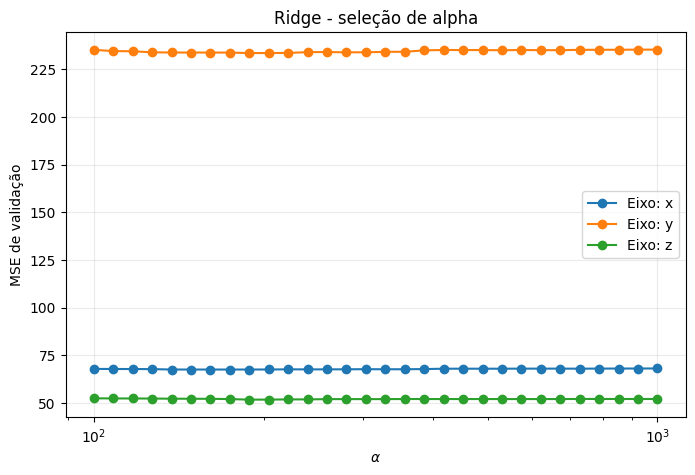

In [43]:
results = ridge_busca
alphas = alphas_ridge
mse = ridge_score

plt.figure(figsize=(8, 5))

eixos=["x", "y", "z"]
tam = len(alphas)

for i in range(3):
    plt.semilogx(
        alphas,
        mse[i*tam:(i+1)*tam],
        marker="o",
        label=f"Eixo: {eixos[i%3]}"
    )

plt.xlabel(r"$\alpha$")
plt.ylabel("MSE de validação")
plt.title("Ridge - seleção de alpha")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

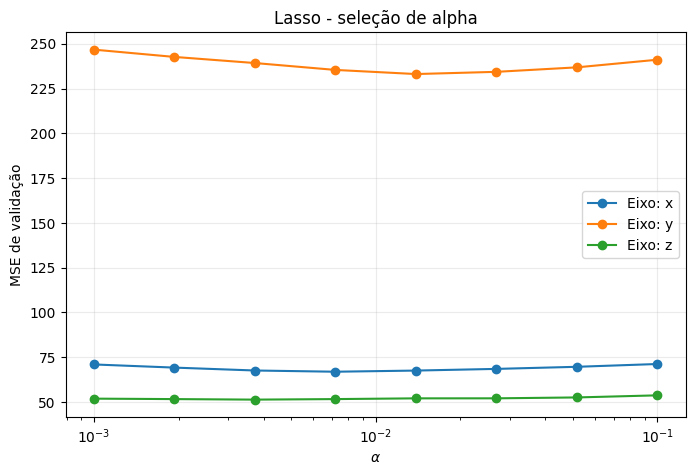

In [44]:
results = lasso_busca
alphas = alphas_lasso
mse = lasso_score

plt.figure(figsize=(8, 5))

eixos=["x", "y", "z"]
tam = len(alphas)

for i in range(3):
    plt.semilogx(
        alphas,
        mse[i*tam:(i+1)*tam],
        marker="o",
        label=f"Eixo: {eixos[i%3]}"
    )

plt.xlabel(r"$\alpha$")
plt.ylabel("MSE de validação")
plt.title("Lasso - seleção de alpha")

plt.grid(alpha=0.25)
plt.legend()

plt.show()

Veja que, para o caso do Lasso, o melhor alpha ainda não foi encontrado (como eles deram o menor valor do intervalo, a suspeita é clara). Mesmo assim, isso provavelmente não irá melhorar muito mais o modelo, mas porque as regularizações foram piores que o OLS? Isso não é uma conclusão absoluta, mesmo o $R^2$ tendo sido visivelmente pior, o MAE não seguiu essa tendencia. Em relação ao $R^2$ ou o RMSE, temos a seguinte ordem:

$${OLS}_{R^2}>{Ridge}_{R^2}\approx {Lasso}_{R^2}$$

$${Ridge}_{RMSE}\approx {Lasso}_{RMSE}>{OLS}_{RMSE}$$

Contudo, ao colocarmos em ordem do MAE, temos:

$${OLS}_{MAE}>{Ridge}_{MAE}>{Lasso}_{MAE}$$

O que isso significa? Mesmo que o desempenho do OLS ultrapasse os outros dois modelos, ele ainda perde quando analisamos na métrica de erro absoluto. Isso mostra que o OLS está mais adaptado para reduzir o RMSE, mas as regularizações conseguiram diminuir mais o MAE. Isso demonstra capacidades diferentes de cada modelo, talvez um MAE menor simbolize erros mais polarizados do que distribuídos e isso seja exatamente o que você busca. A questão é: não podemos bater o pé tão fortemente que um é superior ao outro somente pelo $R^2$, já que os erros são quase idênticos.

Mesmo assim,também não podemos simplesmente ignorar o fato do OLS ter um desempenho superior que os outros modelos, talvez, a resposta seja a mais anticlimática: a regularização feita simplesmente não é boa no problema que estávamos tentando resolver. Sabemos que o OLS se favoreceu com o volume de dados, quem sabe ele fosse a ferramenta certa para resolver isso? Não podemos nos prender a algoritmos e modelos que não funcionam em um dado problema, aceitar a derrota e estudar o motivo da falha. Uma teoria do autor para isso é a utilização individual dessas regularizações. Existe um modelo de regularização que mistura o Ridge com o Lasso chamado ElasticNet <a id='toc0_'></a>[[1]](#toceq_1_), mas ele não será abordado pela extensão atual do notebook.

Outro ponto interessante para se discutir é a tentativa de criar grupos independentes para cada eixo. Analisando a capacidade preditiva, parece que houve uma perda ínfima por separar os eixos, mas existe um ganho em um lugar talvez inesperado: tempo. Mesmo que só usar o <span style="color:#97E1F1">LassoCV</span>() de resultados melhores, o tempo de treino entre o com separação de eixos foi quase metade do que não separava. O <span style="color:#97E1F1">RidgeCV</span>() teve um tempo menor por ter uma solução fixa, então ele pode ser declarado como um que não teve ganho substancial pela separação dos eixos. Entretanto, podemos apontar o fato do nosso Lasso que separava os eixos ainda não encontrou os melhores $\lambda$'s para a demora maior do outro, o Lasso é um modelo que demora muito para convergir quando menor essa variável, então, quem sabe, o motivo dessa diferença de tempo foi o uso de um $\lambda$ maior.

Ademais, veja os coeficientes do Lasso, note que vários deles zeraram. Isso simboliza que muitos resultados o Lasso julgou que não valia a pena manter as características, talvez, o resultado que o OLS encontrou foi um chute que se adéqua aos dados (como vimos em [Valor de casas em terrenos](#toc1_1_6_1_)), mas que não é tão bem interpretável, se for. No entanto, veja esses resultados como preliminares, já que, como o leitor já deve ter notado, avisos de ConvergenceWarning foram emitidos nos treinamentos do Lasso.

Lembre-mos que se esse fosse um problema que pudesse ser simplesmente resolvido com uma ou outra regularização já teríamos uma tecnologia inimaginavelmente avançada nessa área. Por isso, finalizo esse notebook enunciando: antes de aprender a matemática e como aplicar a técnica, entenda suas limitações e o que ela busca.

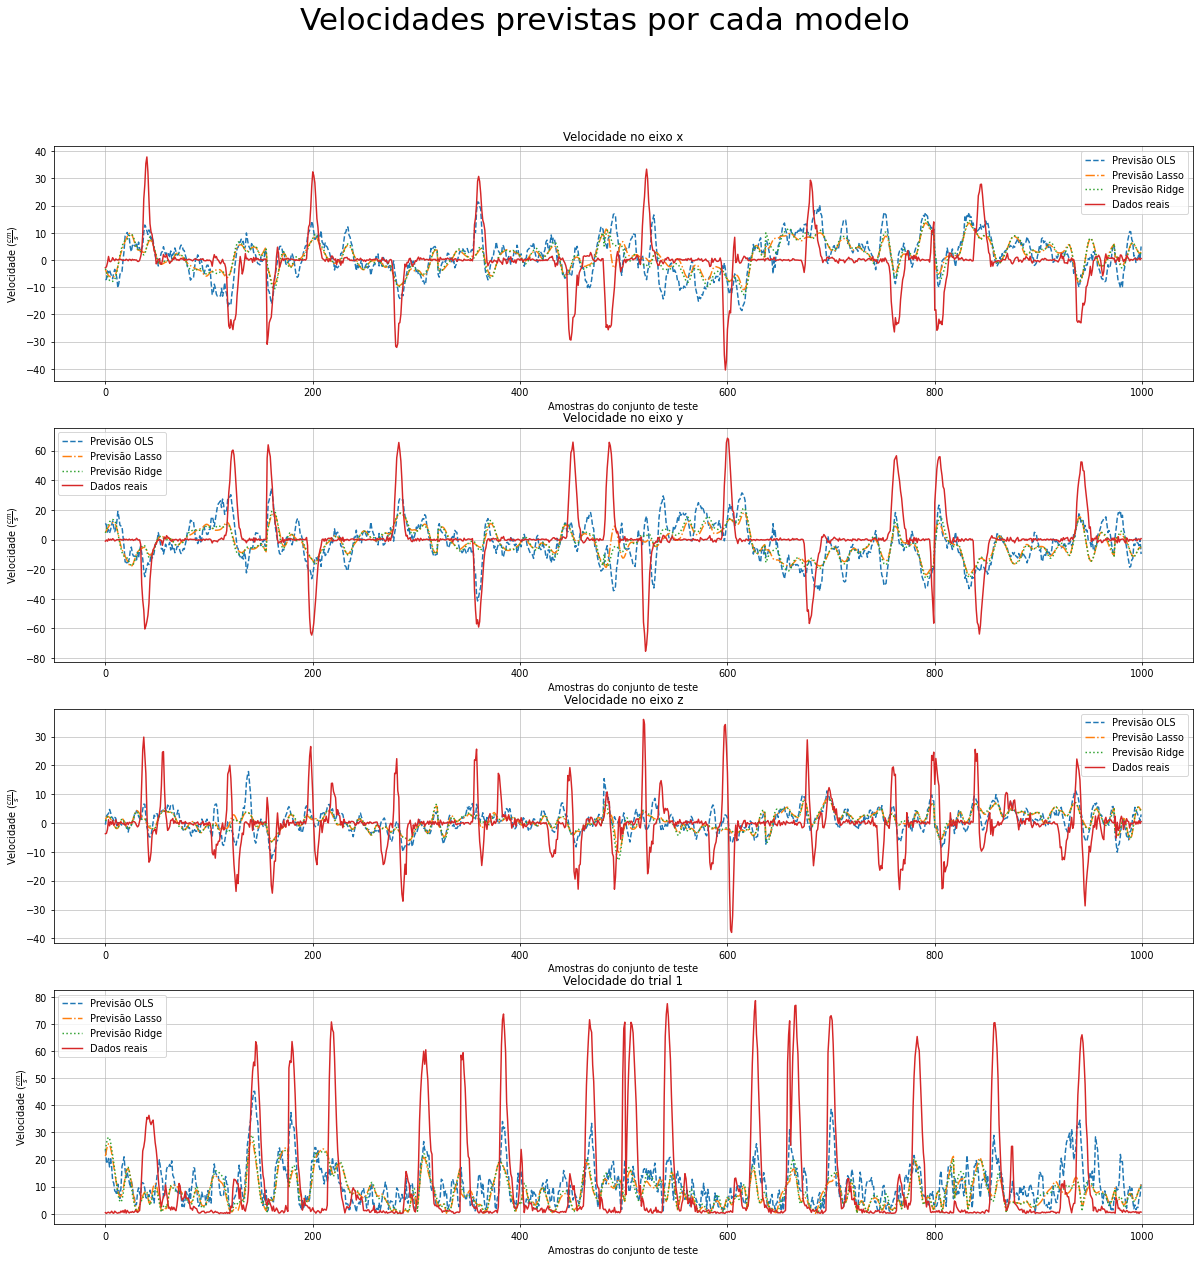

In [46]:
fig, axes = plt.subplots(4,1, figsize=(21, 20), dpi=70)

fig.suptitle('Velocidades previstas por cada modelo', fontsize=32)

espaco = np.linspace(0, X_test.shape[0]-1, X_test.shape[0])

axes[0].plot(espaco[0:1000], Y_pred_ols[0:1000,0], label="Previsão OLS", linestyle="--")
axes[0].plot(espaco[0:1000], Y_pred_lasso[0:1000,0], label="Previsão Lasso", linestyle="-.")
axes[0].plot(espaco[0:1000], Y_pred_ridge[0:1000,0], label="Previsão Ridge", linestyle=":")
axes[0].plot(espaco[0:1000], Y_test[0:1000,0], label="Dados reais")

axes[0].set_ylabel(r"Velocidade ($\frac{cm}{s}$)")
axes[0].set_xlabel(r"Amostras do conjunto de teste")
axes[0].set_title("Velocidade no eixo x")

axes[0].legend()
axes[0].grid(alpha=0.75)

axes[1].plot(espaco[0:1000], Y_pred_ols[0:1000,1], label="Previsão OLS", linestyle="--")
axes[1].plot(espaco[0:1000], Y_pred_lasso[0:1000,1], label="Previsão Lasso", linestyle="-.")
axes[1].plot(espaco[0:1000], Y_pred_ridge[0:1000,1], label="Previsão Ridge", linestyle=":")
axes[1].plot(espaco[0:1000], Y_test[0:1000,1], label="Dados reais")

axes[1].set_ylabel(r"Velocidade ($\frac{cm}{s}$)")
axes[1].set_xlabel(r"Amostras do conjunto de teste")
axes[1].set_title("Velocidade no eixo y")

axes[1].legend()
axes[1].grid(alpha=0.75)

axes[2].plot(espaco[0:1000], Y_pred_ols[0:1000,2], label="Previsão OLS", linestyle="--")
axes[2].plot(espaco[0:1000], Y_pred_lasso[0:1000,2], label="Previsão Lasso", linestyle="-.")
axes[2].plot(espaco[0:1000], Y_pred_ridge[0:1000,2], label="Previsão Ridge", linestyle=":")
axes[2].plot(espaco[0:1000], Y_test[0:1000,2], label="Dados reais")

axes[2].set_ylabel(r"Velocidade ($\frac{cm}{s}$)")
axes[2].set_xlabel(r"Amostras do conjunto de teste")
axes[2].set_title("Velocidade no eixo z")

axes[2].legend()
axes[2].grid(alpha=0.75)

def load_arquivos():

    ws = []
    wins = []

    for i in ws_files[:1]:
        mat = loadmat(i, simplify_cells=True)
        ws.append(mat["ws"])
        wins.append(mat["ws"]["win"])

    return wins, ws

X, Y, _, _ = cria_grupos()

Y = np.linalg.norm(
    Y,
    axis=1
)


Y_trial_ols = np.linalg.norm(
    ols.predict(X),
    axis=1
)

Y_trial_ridge = np.column_stack([
    busca.predict(X) for busca in ridge_busca
])
Y_trial_ridge=np.linalg.norm(
    Y_trial_ridge,
    axis=1
)

Y_trial_lasso = np.column_stack([
    busca.predict(X) for busca in lasso_busca
])
Y_trial_lasso=np.linalg.norm(
    Y_trial_lasso,
    axis=1
)


espaco = np.linspace(0, Y.shape[0]-1, Y.shape[0])

axes[3].plot(espaco[0:1000], Y_trial_ols[0:1000], label="Previsão OLS", linestyle="--")
axes[3].plot(espaco[0:1000], Y_trial_lasso[0:1000], label="Previsão Lasso", linestyle="-.")
axes[3].plot(espaco[0:1000], Y_trial_ridge[0:1000], label="Previsão Ridge", linestyle=":")
axes[3].plot(espaco[0:1000], Y[0:1000], label="Dados reais")

axes[3].set_ylabel(r"Velocidade ($\frac{cm}{s}$)")
axes[3].set_xlabel(r"Amostras do conjunto de teste")
axes[3].set_title("Velocidade do trial 1")

axes[3].legend()
axes[3].grid(alpha=0.75)

plt.show()

Antes de iniciarmos a análise, saiba que os gráficos dos modelos está levemente deslocado da sua posição real. Isso ocorreu pois a previsão era para ser $100 \ ms$ a frente do EEG naquele tempo, mas o gráfico plota ambos como se esse atraso não existisse. Peço um pouco de criatividade do leitor de imaginar que as linhas estão levemente deslocadas para a esquerda.

Para finalizarmos essa tarefa, decidi mostrar um último gráfico. Esse gráfico mostra como, a partir do mesmo EEG, cada modelo prevê a velocidade do pulso. Note que as previsões até tem um padrão, mas nenhuma delas chega perto de acertar. O OLS tem muitos mais picos que os outros modelos, parecendo que ele tenta chutar mais onde tem a intenção de movimento. Já o Ridge e o Lasso ficaram muito parecidos, eles parecem ser mais tímidos nos seus chutes, tendo boas estimativas de onde há o movimento mas sempre chutando uma intensidade baixa.

Ademais, podemos ver aqui um possível motivo do porque o RMSE do OLS foi melhor que os outros modelos enquanto ele perdia no quesito do MAE. Parece que o OLS tem mais chutes fora do estado de equilíbrio (onde $V_{pulso}\approx 0$), porém esses erros não penalizam tanto no RMSE já que são pequenos. Entretanto, a sua estimativa permite chutar valores mais altos quando há um pico real, diminuindo a distância e, por consequência, penalizando muito menos o RMSE. Então, o OLS prevê com uma certa inacurácia inata, mas algumas previsões são relativamente boas, o que diminui o seu RMSE e aumenta o seu MAE.

Obviamente, isso é uma analise visual, existe uma clara limitação no que pode ser extraído visualmente sem aplicarmos alguma analise gráfica. Então o que estamos esperando? Vamos aplicá-las!

...

Será que é necessário? Acredito que já estamos extensos demais até o momento, e pelo que? Conseguir uma ou duas conclusões a mais de algo que já observamos? Deixo aqui essa tarefa ao leitor, acredito que esse seja o fim.

Agradeço imensamente a sua atenção, caro leitor. Espero que esse trabalho tenha conseguido te mostrar o potencial e as limitações da regularização L1 e L2. Qualquer dúvida, basta me contatar pelo email: vinicutolo@gmail.com.

Por fim, caso queira ampliar a sua visão, só há um modo de fazê-la: [clique aqui](https://www.youtube.com/watch?v=dQw4w9WgXcQ)

### <a id='toc1_1_8_'></a>[Apêndice](#toc0_)

<a id='tocap_1_'></a>[{1}](#toc0_) Subgradiente, em resumo, é uma ferramenta matemática especifica do ramo de otimização convexa. Imagine que tenhamos um ponto que não apresenta derivada direcional, para podermos continuar com o código e gerar formas de otimização desse tipo de função, dizemos que o gradiente daquele ponto está em um intervalo que respeite a convexidade daquele ponto. Por isso, subgradiente é uma generalização da derivada comum para pontos não suaves.

<a id='tocap_2_'></a>[{2}](#toc0_) A decomposição SVD é um método numérico importante da algebra linear que decompõe qualquer matriz, real ou complexa. Essa técnica transforma a matriz original em três outras: U, $\Sigma$ e $V^T$. Em especial, essas matrizes tem os seus valores singulares explícitos, o que da muita informação sobre a matriz/sistema original.

<a id='tocap_3_'></a>[{3}](#toc0_) Podemos estimar esse valor usando a área urbanizada residencial do Brasil e o número de domicílios. Usando o valor de $53.925 \ km^2$ de área domiciliar [7] e e de que há $79,3$ milhões de casas no Brasil [8], podemos dividir esses valores para estimar que o valor médio do terreno no Brasil é de $680 \ m^2$. Obviamente, isso é uma estimativa extremamente grosseira, mas serve para os propósitos do notebook.  

### <a id='toc1_1_9_'></a>[Referências](#toc0_)

<a id='toceq_1_'></a>[[1]](#toc0_) JAMES, Gareth; WITTEN, Daniela; HASTIE, Trevor; et al. An Introduction to
Statistical Learning: with Applications in Python. 2023. Disponível em:
https://www.statlearning.com

<a id='toceq_2_'></a>[[2]](#toc0_) FACELI, Katti; LORENA, AC; GAMA, João; et al. Inteligência Artificial: uma abordagem de Aprendizado de Máquina. 2. ed. 2021.

<a id='toceq_3_'></a>[[3]](#toc0_) HASTIE, Trevor; TIBSHIRANI, Robert; FRIEDMAN, Jerome. The Elements of
Statistical Learning. 2nd ed. 2009. sec: 3.4. Disponível em: https://hastie.su.domains/ElemStatLearn/.

<a id='toceq_4_'></a>[[4]](#toc0_) Krogh, A.; Hertz, J.A. A Simple Weight Decay Can Improve Generalization. Advances in Neural Information Processing Systems 4 (NeurIPS 1991), p. 950–957

<a id='toceq_5_'></a>[[5]](#toc0_) TIBSHIRANI, Robert. Regression shrinkage and selection via the lasso. Journal of the Royal Statistical Society: Series B (Methodological), London, v. 58, n. 1, p. 267-288, 1996. DOI: https://doi.org/10.1111/j.2517-6161.1996.tb02080.x. Disponível em: https://doi.org/10.1111/j.2517-6161.1996.tb02080.x. Acesso em: 18 ago. 2026.

<a id='toceq_6_'></a>[[6]](#toc0_) BOYD, Stephen; VANDENBERGHE, Lieven. Convex optimization. Cambridge: Cambridge University Press, 2004. Disponível em: https://web.stanford.edu/~boyd/cvxbook/bv_cvxbook.pdf. Acesso em: 18 ago. 2026.

<a id='toceq_7_'></a>[[7]](#toc0_) INSTITUTO BRASILEIRO DE GEOGRAFIA E ESTATÍSTICA (IBGE). Urbanizadas 2022. Agência de Notícias IBGE, Rio de Janeiro, 2025. Disponível em: <https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/47788-urbanizadas2022>. Acesso em: 19 ago. 2026.

<a id='toceq_8_'></a>[[8]](#toc0_) INSTITUTO BRASILEIRO DE GEOGRAFIA E ESTATÍSTICA (IBGE). Domicílios alugados cresceram mais de 50% desde 2016. Agência de Notícias IBGE, Rio de Janeiro, 2025. Disponível em: <https://agenciadenoticias.ibge.gov.br/agencia-noticias/2012-agencia-de-noticias/noticias/46449-domicilios-alugados-cresceram-mais-de-50-desde-2016>. Acesso em: 19 ago. 2026.

<a id='toceq_9_'></a>[[9]](#toc0_) LUCIW, Matthew David; JAROCKA, Ewa; EDIN, Benoni. WAY-EEG-GAL: Multi-channel EEG Recordings During 3,936 Grasp and Lift Trials with Varying Weight and Friction. Figshare, 2014. DOI: 10.6084/m9.figshare.c.988376.v2.

<a id='toceq_10_'></a>[[10]](#toc0_) BRADBERRY, Trent J.; GENTILI, Rodolphe J.; CONTRERAS-VIDAL, José L. Reconstructing three-dimensional hand movements from noninvasive electroencephalographic signals. The Journal of Neuroscience, v. 30, n. 9, p. 3432-3437, 2010. DOI: https://doi.org/10.1523/JNEUROSCI.6107-09.2010. Disponível em: https://www.jneurosci.org/content/30/9/3432. Acesso em: 22 ago. 2026.

<a id='toceq_11_'></a>[[11]](#toc0_) LUCIW, Matthew D.; JAROCKA, Ewa; EDIN, Benoni B. Multi-channel EEG recordings during 3,936 grasp and lift trials with varying weight and friction. Scientific Data, v. 1, 140047, 2014. DOI: 10.1038/sdata.2014.47.

<a id='toceq_12_'></a>[[12]](#toc0_) YAO, Dezhong; QIN, Yun; HU, Shiang; et al. Which Reference Should We Use for EEG and ERP Practice? Brain Topography, v. 32, p. 530–549, 2019. DOI: 10.1007/s10548-019-00707-x.

<a id='toceq_13_'></a>[[13]](#toc0_) SCIPY COMMUNITY. SciPy documentation. SciPy. Disponível em: <https://docs.scipy.org/doc/scipy/index.html>. Acesso em: 28 ago. 2026.

<a id='toceq_14_'></a>[[14]](#toc0_) SCIKIT-LEARN DEVELOPERS. User Guide. Scikit-learn. Disponível em: <https://scikit-learn.org/stable/user_guide.html>. Acesso em: 28 ago. 2026.

### Descrição do uso de IA neste trabalho

Ao todo, foram usadas três IAs para auxiliar esse notebook: Copilot, ChatGPT e o Claude. Cada qual teve uma atuação específica nesse notebook:

Copilot: ele foi usado majoritariamente para criar referências a partir de PDFs ou links e para corrigir plots gráficos no matplotlib. As referências geradas foram conferidas em relação as originais para garantir que o conteúdo estava correto. Ele não tem link de conversa e acredito que nem seria útil disponibilizá-lo aqui, já que nada muito relevante foi obtido além de formatação.

Chat-GPT: o chatGPT foi o principal tutor de estudos sobre o assunto. Ele que tirava dúvidas durante o aprendizado e ajudou a corrigir algumas interpretações errôneas. Ele também foi usado para revisar diversos trechos teóricos dentro do notebook. Infelizmente, todo o estudo está espalhado em uma conversa que tem outros assuntos misturados, por isso, uma recriação foi feita dentro de um chat separado. A conversa reconstruída pode ser encontrada nesse link: [ChatGPT.com](https://chatgpt.com/share/6a91ec1b-38d4-83e9-8da2-00929453f825), ela remonta os principais pontos discutidos dentro do Chat, mas não é a conversa original.

Claude: esse foi o principal corretor e revisor dos códigos e corretor de bugs. Ele que sugeriu e explicou o uso de: Subgradiente, o dataset usado na parte de EEG, separar em janelas temporais, criar os gráficos no espaço de soluções de L2 e L1, usar GroupShuffle e GroupKFold, usar o resample e o sosfilt e outros filtros. Além disso, erros dentro do código foram diagnosticados por ele, como parâmetros dentro do código, formas melhores de organizar algumas funções, etc, como no caso da função de treino ``busca_modelo_eixo_CV``. Ademais, ele que sugeriu o uso de algumas referências em alguns assuntos não só para aprofundar o conhecimento, mas para referenciar corretamente alguns trechos do notebook. Em geral, toda a lógica dentro do notebook foi completamente de autoria do estudante, mas algumas formas de solucionar os problemas propostos vieram da IA. O link da conversa pode ser encontrado em: [Claude.ia](https://claude.ai/share/0a165c7e-1681-4155-a8cd-1e8610b4fe10)